<a href="https://colab.research.google.com/github/charan327/DataScienceProject/blob/main/another_copy_of_eda_movielens_ui.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


MOVIELENS_DIR = r"C:\ml-latest-small"



import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# UI requires ipywidgets. If it fails, you can ignore UI and use manual cells below.
try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    WIDGETS_AVAILABLE = True
except Exception as e:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available here. You can still run the notebook without UI.")
    print("Error:", e)


In [ ]:
!unzip ml-latest-small.zip


Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [ ]:
# Global variables to hold dataframes after loading
ratings = None
movies = None
tags = None

def load_movielens(folder: str):
    folder_path = Path(folder).expanduser().resolve()
    ratings_path = folder_path / "ratings.csv"
    movies_path = folder_path / "movies.csv"
    tags_path = folder_path / "tags.csv"

    if not ratings_path.exists() or not movies_path.exists():
        raise FileNotFoundError(
            f"Could not find ratings.csv and movies.csv in: {folder_path}\n"
            f"Found ratings.csv: {ratings_path.exists()} | movies.csv: {movies_path.exists()}\n"
            f"Tip: set MOVIELENS_DIR to your dataset folder or copy the correct path into the UI."
        )

    r = pd.read_csv(ratings_path)
    m = pd.read_csv(movies_path)
    t = pd.read_csv(tags_path) if tags_path.exists() else None
    return r, m, t

def basic_quality_checks(r: pd.DataFrame, m: pd.DataFrame, t: pd.DataFrame | None):
    out = {}
    out["ratings_shape"] = r.shape
    out["movies_shape"] = m.shape
    out["tags_shape"] = None if t is None else t.shape

    out["ratings_missing"] = r.isna().sum()
    out["movies_missing"] = m.isna().sum()
    out["tags_missing"] = None if t is None else t.isna().sum()

    out["ratings_duplicates"] = int(r.duplicated().sum())
    out["movies_duplicates"] = int(m.duplicated().sum())
    out["tags_duplicates"] = None if t is None else int(t.duplicated().sum())

    return out

def dataset_summary(r: pd.DataFrame):
    # number of unique users, movies, and total ratings
    n_users = r["userId"].nunique()
    n_movies = r["movieId"].nunique()
    n_ratings = len(r)
    sparsity = 1 - (n_ratings / (n_users * n_movies))
    return n_users, n_movies, n_ratings, sparsity

def plot_rating_distribution(r: pd.DataFrame):
    plt.figure()
    r["rating"].hist(bins=10)
    plt.title("Rating distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

def plot_ratings_per_user(r: pd.DataFrame):
    counts = r.groupby("userId")["movieId"].count()
    plt.figure()
    counts.hist(bins=50)
    plt.title("Ratings per user (user activity)")
    plt.xlabel("Number of ratings")
    plt.ylabel("Number of users")
    plt.show()
    return counts

def plot_ratings_per_movie(r: pd.DataFrame):
    counts = r.groupby("movieId")["userId"].count()
    plt.figure()
    counts.hist(bins=50)
    plt.title("Ratings per movie (popularity)")
    plt.xlabel("Number of ratings")
    plt.ylabel("Number of movies")
    plt.show()
    return counts

def simple_cleaning(r: pd.DataFrame, m: pd.DataFrame, t: pd.DataFrame | None):
    # Keep a copy
    r2 = r.copy()
    m2 = m.copy()
    t2 = None if t is None else t.copy()

    # Convert dtypes (safe, helps later)
    r2["userId"] = r2["userId"].astype(int)
    r2["movieId"] = r2["movieId"].astype(int)
    r2["rating"] = r2["rating"].astype(float)
    if "timestamp" in r2.columns:
        r2["timestamp"] = pd.to_datetime(r2["timestamp"], unit="s", errors="coerce")

    m2["movieId"] = m2["movieId"].astype(int)
    if "genres" in m2.columns:
        m2["genres"] = m2["genres"].fillna("")

    if t2 is not None:
        t2["userId"] = t2["userId"].astype(int)
        t2["movieId"] = t2["movieId"].astype(int)
        if "timestamp" in t2.columns:
            # MovieLens tags typically also have Unix timestamps
            t2["timestamp"] = pd.to_datetime(t2["timestamp"], unit="s", errors="coerce")
        if "tag" in t2.columns:
            t2["tag"] = t2["tag"].astype(str).fillna("")

    # Drop exact duplicate rows
    r2 = r2.drop_duplicates()
    m2 = m2.drop_duplicates()
    if t2 is not None:
        t2 = t2.drop_duplicates()

    return r2, m2, t2

def build_ui():
    if not WIDGETS_AVAILABLE:
        return

    path_box = widgets.Text(
        value=MOVIELENS_DIR,
        description="Dataset folder:",
        placeholder="Paste folder path containing ratings.csv and movies.csv",
        layout=widgets.Layout(width="80%")
    )
    load_btn = widgets.Button(description="Load dataset", button_style="primary")
    run_btn = widgets.Button(description="Run EDA + Plots", button_style="success")
    clean_btn = widgets.Button(description="Run Cleaning", button_style="warning")

    user_dropdown = widgets.Dropdown(options=[], description="User:", disabled=True)
    topn_slider = widgets.IntSlider(value=10, min=5, max=30, step=1, description="Top N:")
    show_user_btn = widgets.Button(description="Show user's top rated movies", button_style="info")

    output = widgets.Output()

    def on_load_clicked(_):
        nonlocal user_dropdown
        global ratings, movies, tags
        with output:
            clear_output()
            try:
                ratings, movies, tags = load_movielens(path_box.value.strip())
                display(Markdown("**Dataset loaded successfully.**"))
                display(Markdown(f"- ratings: `{ratings.shape}`\n- movies: `{movies.shape}`\n- tags: `{None if tags is None else tags.shape}`"))

                # Populate user dropdown
                user_ids = sorted(ratings["userId"].unique().tolist())
                user_dropdown.options = user_ids[:500]  # limit for UI responsiveness
                user_dropdown.disabled = False
                display(Markdown(" User dropdown enabled (showing first 500 users for speed)."))
            except Exception as e:
                display(Markdown(f" **Load failed:** {e}"))

    def on_run_clicked(_):
        global ratings, movies, tags
        with output:
            clear_output()
            if ratings is None or movies is None:
                display(Markdown(" Please load the dataset first."))
                return

            qc = basic_quality_checks(ratings, movies, tags)
            n_users, n_movies, n_ratings, sparsity = dataset_summary(ratings)

            display(Markdown("##  Quick Summary"))
            display(Markdown(f"- Users: **{n_users:,}**\n- Movies: **{n_movies:,}**\n- Ratings: **{n_ratings:,}**\n- Sparsity (approx): **{sparsity:.4f}**"))

            display(Markdown("## Data Quality Checks"))
            display(Markdown(f"**Duplicates (rows):** ratings={qc['ratings_duplicates']} | movies={qc['movies_duplicates']} | tags={qc['tags_duplicates']}"))
            display(Markdown("**Missing values (top columns):**"))
            display(pd.DataFrame({
                "ratings_missing": qc["ratings_missing"],
            }).sort_values("ratings_missing", ascending=False).head(10))

            display(Markdown("## 📊 Key Plots"))
            plot_rating_distribution(ratings)
            plot_ratings_per_user(ratings)
            plot_ratings_per_movie(ratings)

            display(Markdown("##  Notes (for supervision)"))
            display(Markdown(
                "- Ratings often skew higher (positive bias).\n"
                "- Ratings per user show sparsity (many users rate few items).\n"
                "- Ratings per movie show popularity bias (few movies dominate)."
            ))

    def on_clean_clicked(_):
        global ratings, movies, tags
        with output:
            clear_output()
            if ratings is None or movies is None:
                display(Markdown(" Please load the dataset first."))
                return
            before_r, before_m = ratings.shape, movies.shape
            ratings, movies, tags = simple_cleaning(ratings, movies, tags)
            after_r, after_m = ratings.shape, movies.shape
            display(Markdown(" **Cleaning complete.**"))
            display(Markdown(f"- ratings: {before_r} → {after_r}\n- movies: {before_m} → {after_m}"))
            display(Markdown("Applied: dtype fixes, timestamp conversion (if present), removed duplicates, filled missing genres."))

    def on_show_user_clicked(_):
        global ratings, movies
        with output:
            display(Markdown("---"))
            if ratings is None or movies is None:
                display(Markdown(" Please load the dataset first."))
                return
            uid = user_dropdown.value
            n = int(topn_slider.value)
            user_r = ratings[ratings["userId"] == uid].sort_values("rating", ascending=False).head(n)
            merged = user_r.merge(movies, on="movieId", how="left")[["userId", "movieId", "title", "genres", "rating"]]
            display(Markdown(f"### 🎬 Top rated movies for user **{uid}** (Top {n})"))
            display(merged.reset_index(drop=True))

    load_btn.on_click(on_load_clicked)
    run_btn.on_click(on_run_clicked)
    clean_btn.on_click(on_clean_clicked)
    show_user_btn.on_click(on_show_user_clicked)

    controls = widgets.VBox([
        path_box,
        widgets.HBox([load_btn, run_btn, clean_btn]),
        widgets.HBox([user_dropdown, topn_slider, show_user_btn])
    ])

    display(controls, output)

build_ui()


Output()

In [ ]:
# Quick sanity check
print("ratings:", ratings.shape)
print("movies :", movies.shape)

ratings.head()


ratings: (100836, 4)
movies : (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
# Popularity-based recommender
# Popularity = movies with most ratings

pop_counts = ratings.groupby("movieId")["rating"].size().sort_values(ascending=False)

topN = 10
top_popular = pop_counts.head(topN).reset_index(name="num_ratings")

top_popular = top_popular.merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")

top_popular[["movieId", "title", "genres", "num_ratings"]]


,movieId,title,genres,num_ratings
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
1,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
3,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
4,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
5,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
6,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
7,110,Braveheart (1995),Action|Drama|War,237
8,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
9,527,Schindler's List (1993),Drama|War,220


In [ ]:
# Popularity + quality

movie_stats = ratings.groupby("movieId")["rating"].agg(["count", "mean"]).reset_index()
movie_stats = movie_stats.rename(columns={"count": "num_ratings", "mean": "avg_rating"})

min_ratings = 50  # you can change: 20, 50, 100
filtered = movie_stats[movie_stats["num_ratings"] >= min_ratings]

top_quality_popular = (
    filtered.sort_values(["avg_rating", "num_ratings"], ascending=[False, False])
            .head(10)
            .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
)

top_quality_popular[["movieId", "title", "genres", "num_ratings", "avg_rating"]]


,movieId,title,genres,num_ratings,avg_rating
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
1,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
3,1276,Cool Hand Luke (1967),Drama,57,4.271930
4,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
5,904,Rear Window (1954),Mystery|Thriller,84,4.261905
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
7,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
8,1213,Goodfellas (1990),Crime|Drama,126,4.250000
9,912,Casablanca (1942),Drama|Romance,100,4.240000


In [ ]:
# Create user-item matrix for similarity model

user_movie = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    aggfunc="mean"
).fillna(0)

print("User-movie matrix shape:", user_movie.shape)
user_movie.iloc[:5, :5]


User-movie matrix shape: (610, 9724)


movieId,1,2,3,4,5
userId,,,,,
1,4.0,0.0,4.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Compute cosine similarity between movies
movie_sim = cosine_similarity(user_movie.T)

movie_sim_df = pd.DataFrame(
    movie_sim,
    index=user_movie.columns,
    columns=user_movie.columns
)

movie_sim_df.iloc[:5, :5]


movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762
2,0.410562,1.000000,0.282438,0.106415,0.287795
3,0.296917,0.282438,1.000000,0.092406,0.417802
4,0.035573,0.106415,0.092406,1.000000,0.188376
5,0.308762,0.287795,0.417802,0.188376,1.000000


In [ ]:
def recommend_similar_movies(movie_id: int, top_n: int = 10):
    if movie_id not in movie_sim_df.columns:
        return f"movieId {movie_id} not found in similarity matrix."

    sims = movie_sim_df[movie_id].sort_values(ascending=False)

    sims = sims.iloc[1:top_n+1].reset_index()
    sims.columns = ["movieId", "similarity"]

    result = sims.merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
    return result

# Example: choose a movieId that exists in your dataset
recommend_similar_movies(movie_id=1, top_n=10)


,movieId,similarity,title,genres
0,3114,0.572601,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
1,480,0.565637,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
2,780,0.564262,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
3,260,0.557388,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,356,0.547096,Forrest Gump (1994),Comedy|Drama|Romance|War
5,364,0.541145,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
6,1210,0.541089,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
7,648,0.538913,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
8,1265,0.534169,Groundhog Day (1993),Comedy|Fantasy|Romance
9,1270,0.530381,Back to the Future (1985),Adventure|Comedy|Sci-Fi


In [ ]:
def find_movie_ids(title_contains: str, n: int = 10):
    return movies[movies["title"].str.contains(title_contains, case=False, na=False)][["movieId", "title"]].head(n)

find_movie_ids("Toy Story")


,movieId,title
0,1,Toy Story (1995)
2355,3114,Toy Story 2 (1999)
7355,78499,Toy Story 3 (2010)


In [ ]:
recommend_similar_movies(movie_id=780, top_n=10)


,movieId,similarity,title,genres
0,648,0.677354,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
1,480,0.638418,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
2,736,0.620618,Twister (1996),Action|Adventure|Romance|Thriller
3,1210,0.588853,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
4,589,0.588414,Terminator 2: Judgment Day (1991),Action|Sci-Fi
5,260,0.584450,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,1,0.564262,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
7,733,0.561085,"Rock, The (1996)",Action|Adventure|Thriller
8,32,0.559553,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
9,1240,0.536818,"Terminator, The (1984)",Action|Sci-Fi|Thriller


In [ ]:
import pandas as pd
import numpy as np

ratings_sorted = ratings.sort_values(["userId", "timestamp"])

test = ratings_sorted.groupby("userId").tail(1)

train = ratings_sorted.drop(test.index)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (100226, 4)
Test shape: (610, 4)


In [ ]:
train_matrix = train.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

print("Train matrix shape:", train_matrix.shape)
train_matrix.head()

Train matrix shape: (610, 9701)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(train_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

item_similarity_df.iloc[:5, :5]

movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.412963,0.300894,0.035573,0.302372
2,0.412963,1.000000,0.287895,0.107037,0.277473
3,0.300894,0.287895,1.000000,0.093644,0.427248
4,0.035573,0.107037,0.093644,1.000000,0.190089
5,0.302372,0.277473,0.427248,0.190089,1.000000


In [ ]:
popular_movies = (
    train.groupby("movieId")["rating"]
    .count()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [ ]:
def recommend_popularity(user_id, k=10):
    if user_id in train_matrix.index:
        already_rated = set(train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index)
    else:
        already_rated = set()

    recs = [m for m in popular_movies if m not in already_rated]
    return recs[:k]

In [ ]:
def recommend_item_based(user_id, k=10):
    if user_id not in train_matrix.index:
        return []

    user_ratings = train_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]

    if len(rated_movies) == 0:
        return []

    scores = pd.Series(0.0, index=train_matrix.columns)

    for movie_id, rating in rated_movies.items():
        scores += item_similarity_df[movie_id] * rating

    # remove already rated movies
    scores = scores.drop(rated_movies.index, errors="ignore")

    top_k = scores.sort_values(ascending=False).head(k).index.tolist()
    return top_k

In [ ]:
def evaluate_precision_recall(model_func, k=10):
    hits = 0
    total_users = 0

    for _, row in test.iterrows():
        user_id = row["userId"]
        true_movie = row["movieId"]

        recs = model_func(user_id, k=k)

        if len(recs) == 0:
            continue

        total_users += 1
        if true_movie in recs:
            hits += 1

    precision = hits / (total_users * k) if total_users > 0 else 0
    recall = hits / total_users if total_users > 0 else 0

    return precision, recall, hits, total_users

In [ ]:
import math

def evaluate_ndcg(model_func, k=10):
    ndcg_scores = []

    for _, row in test.iterrows():
        user_id = row["userId"]
        true_movie = row["movieId"]

        recs = model_func(user_id, k=k)

        if len(recs) == 0:
            continue

        if true_movie in recs:
            rank = recs.index(true_movie) + 1  # rank starts at 1
            dcg = 1 / math.log2(rank + 1)
            idcg = 1.0
            ndcg = dcg / idcg
        else:
            ndcg = 0.0

        ndcg_scores.append(ndcg)

    return np.mean(ndcg_scores) if len(ndcg_scores) > 0 else 0

In [ ]:
for k in [5, 10, 20]:
    p_pop, r_pop, hits_pop, users_pop = evaluate_precision_recall(recommend_popularity, k=k)
    ndcg_pop = evaluate_ndcg(recommend_popularity, k=k)

    p_item, r_item, hits_item, users_item = evaluate_precision_recall(recommend_item_based, k=k)
    ndcg_item = evaluate_ndcg(recommend_item_based, k=k)

    print(f"\n===== K = {k} =====")
    print("Popularity Model")
    print(f"Precision@{k}: {p_pop:.4f}")
    print(f"Recall@{k}: {r_pop:.4f}")
    print(f"NDCG@{k}: {ndcg_pop:.4f}")

    print("\nItem-Based CF Model")
    print(f"Precision@{k}: {p_item:.4f}")
    print(f"Recall@{k}: {r_item:.4f}")
    print(f"NDCG@{k}: {ndcg_item:.4f}")


===== K = 5 =====
Popularity Model
Precision@5: 0.0052
Recall@5: 0.0262
NDCG@5: 0.0143

Item-Based CF Model
Precision@5: 0.0056
Recall@5: 0.0279
NDCG@5: 0.0173

===== K = 10 =====
Popularity Model
Precision@10: 0.0041
Recall@10: 0.0410
NDCG@10: 0.0189

Item-Based CF Model
Precision@10: 0.0064
Recall@10: 0.0639
NDCG@10: 0.0290

===== K = 20 =====
Popularity Model
Precision@20: 0.0035
Recall@20: 0.0705
NDCG@20: 0.0263

Item-Based CF Model
Precision@20: 0.0052
Recall@20: 0.1049
NDCG@20: 0.0394


In [ ]:
results = []

for k in [5, 10, 20]:
    p_pop, r_pop, _, _ = evaluate_precision_recall(recommend_popularity, k=k)
    ndcg_pop = evaluate_ndcg(recommend_popularity, k=k)

    p_item, r_item, _, _ = evaluate_precision_recall(recommend_item_based, k=k)
    ndcg_item = evaluate_ndcg(recommend_item_based, k=k)

    results.append(["Popularity", k, p_pop, r_pop, ndcg_pop])
    results.append(["Item-CF", k, p_item, r_item, ndcg_item])

results_df = pd.DataFrame(results, columns=["Model", "K", "Precision@K", "Recall@K", "NDCG@K"])
results_df

,Model,K,Precision@K,Recall@K,NDCG@K
0,Popularity,5,0.005246,0.026230,0.014302
1,Item-CF,5,0.005574,0.027869,0.017337
2,Popularity,10,0.004098,0.040984,0.018909
3,Item-CF,10,0.006393,0.063934,0.028980
4,Popularity,20,0.003525,0.070492,0.026300
5,Item-CF,20,0.005246,0.104918,0.039397


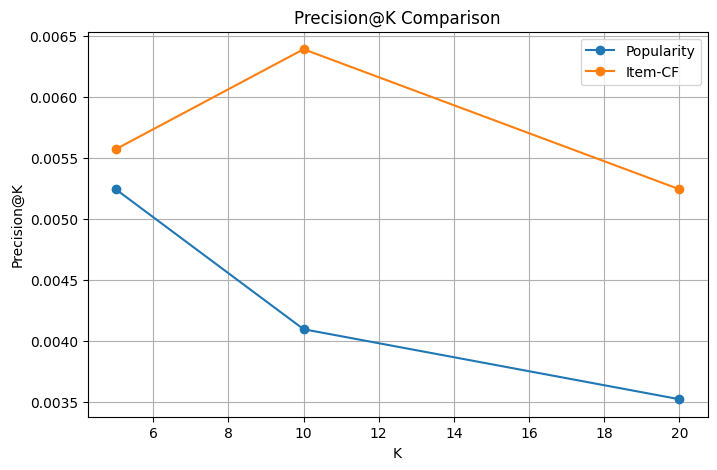

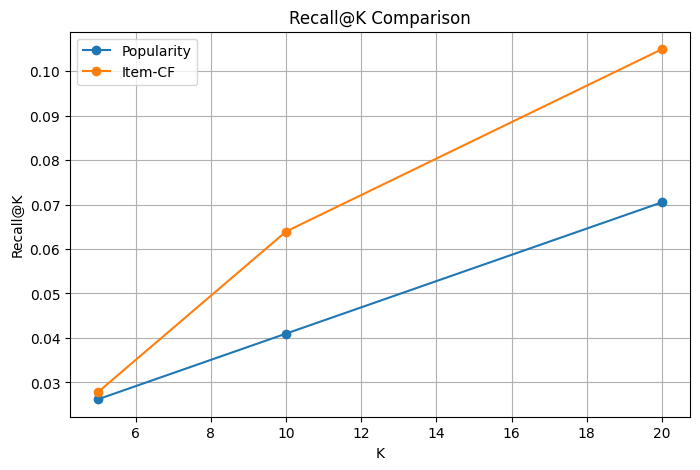

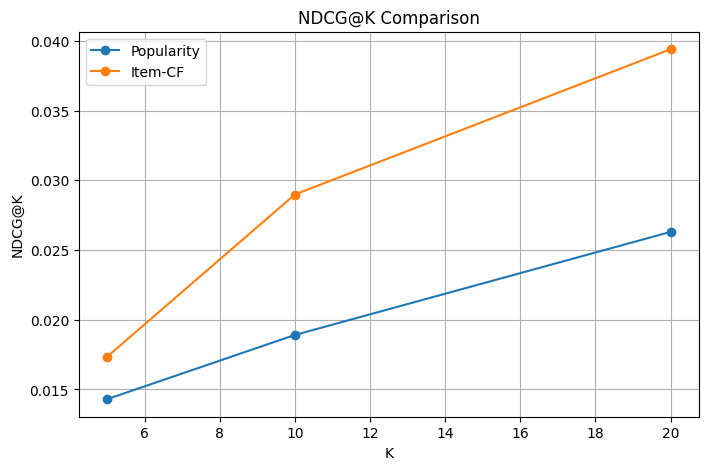

In [ ]:
import matplotlib.pyplot as plt

for metric in ["Precision@K", "Recall@K", "NDCG@K"]:
    plt.figure(figsize=(8,5))
    for model in results_df["Model"].unique():
        subset = results_df[results_df["Model"] == model]
        plt.plot(subset["K"], subset[metric], marker="o", label=model)

    plt.title(f"{metric} Comparison")
    plt.xlabel("K")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()